# Atlas HR Consulting — Salary Benchmarking
### Session notebook · Linear, Multiple & Polynomial Regression

**Atlas HR Consulting** has been hired by a mid-size company to benchmark its salaries.
The client handed over anonymized payroll data for 1,500 employees and wants to know:

1. Can we build a model that predicts a **fair monthly salary** from an employee's
   experience, education, role, city and company?
2. Does adding **more features** (multiple regression) actually help over using
   experience alone?
3. Does salary grow **linearly** with experience, or is something more curved going on?

We'll answer all three by building three regression models — simple, multiple, and
polynomial — on the same data, and comparing them with **R²**, **MSE** and **RMSE**.

**How this notebook works:** sections 1-7 (loading, EDA, cleaning, encoding) are done
for you — read them, they set up everything you need. Starting at **§8 (train/test
split)**, you take over: each code cell has a `# TODO` comment explaining exactly what
to do and which feature(s) to use, but the code itself is yours to write.


---
## 1. Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder

%matplotlib inline
RANDOM_STATE = 42

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

print("Setup complete ✓")

Setup complete ✓


---
## 2. Load the data — basic info


In [2]:
df = pd.read_csv("attachment-1788468291382-NGADrXaKJmRCwZHZ4b89Fi9ACa9IrI.csv")
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (1500, 11)


,employee_id,age,years_experience,education_level,role,city,company_size,performance_rating,remote_work,gender,monthly_salary_dzd
0,EMP0001,33,5.40,Master,HR Specialist,Annaba,Small,2,No,Male,69000
1,EMP0002,23,0.00,Bachelor,Sales Representative,Blida,Medium,5,No,Male,66000
2,EMP0003,35,9.40,Bachelor,Accountant,Oran,Medium,4,Yes,Female,104000
3,EMP0004,34,12.90,Master,HR Specialist,Oran,Medium,4,No,Male,102000
4,EMP0005,26,5.50,High School,Software Engineer,Setif,Small,4,No,Male,79500


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         1500 non-null   str    
 1   age                 1500 non-null   int64  
 2   years_experience    1500 non-null   float64
 3   education_level     1500 non-null   str    
 4   role                1500 non-null   str    
 5   city                1500 non-null   str    
 6   company_size        1500 non-null   str    
 7   performance_rating  1500 non-null   int64  
 8   remote_work         1500 non-null   str    
 9   gender              1500 non-null   str    
 10  monthly_salary_dzd  1500 non-null   int64  
dtypes: float64(1), int64(3), str(7)
memory usage: 199.9 KB


In [4]:
df.describe()

,age,years_experience,performance_rating,monthly_salary_dzd
count,"1,500.00","1,500.00","1,500.00","1,500.00"
mean,37.88,15.01,3.42,"104,811.00"
std,8.54,8.75,0.94,"29,574.67"
min,22.00,0.00,1.00,"37,500.00"
25%,32.00,9.00,3.00,"83,500.00"
50%,38.00,14.65,3.00,"101,000.00"
75%,43.00,20.52,4.00,"120,500.00"
max,63.00,40.00,5.00,"263,500.00"


In [5]:
df.describe(include="object")

C:\Users\cherchell pc\AppData\Local\Temp\ipykernel_17708\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,employee_id,education_level,role,city,company_size,remote_work,gender
count,1500,1500,1500,1500,1500,1500,1500
unique,1500,4,9,6,3,2,2
top,EMP0001,Bachelor,Sales Representative,Alger,Medium,No,Male
freq,1,724,226,463,594,1139,755


**What we're looking at:** each row is one employee. `employee_id` is just a label.
`monthly_salary_dzd` is our **target**. Everything else — `age`, `years_experience`,
`education_level`, `role`, `city`, `company_size`, `performance_rating`, `remote_work`,
`gender` — is a candidate feature.

Two columns need a closer look before we model anything: `education_level` has a
**natural order** (High School < Bachelor < Master < PhD), while `role` and `city` do
**not** — that difference will matter a lot when we encode them later.


---
## 3. EDA — numerical features


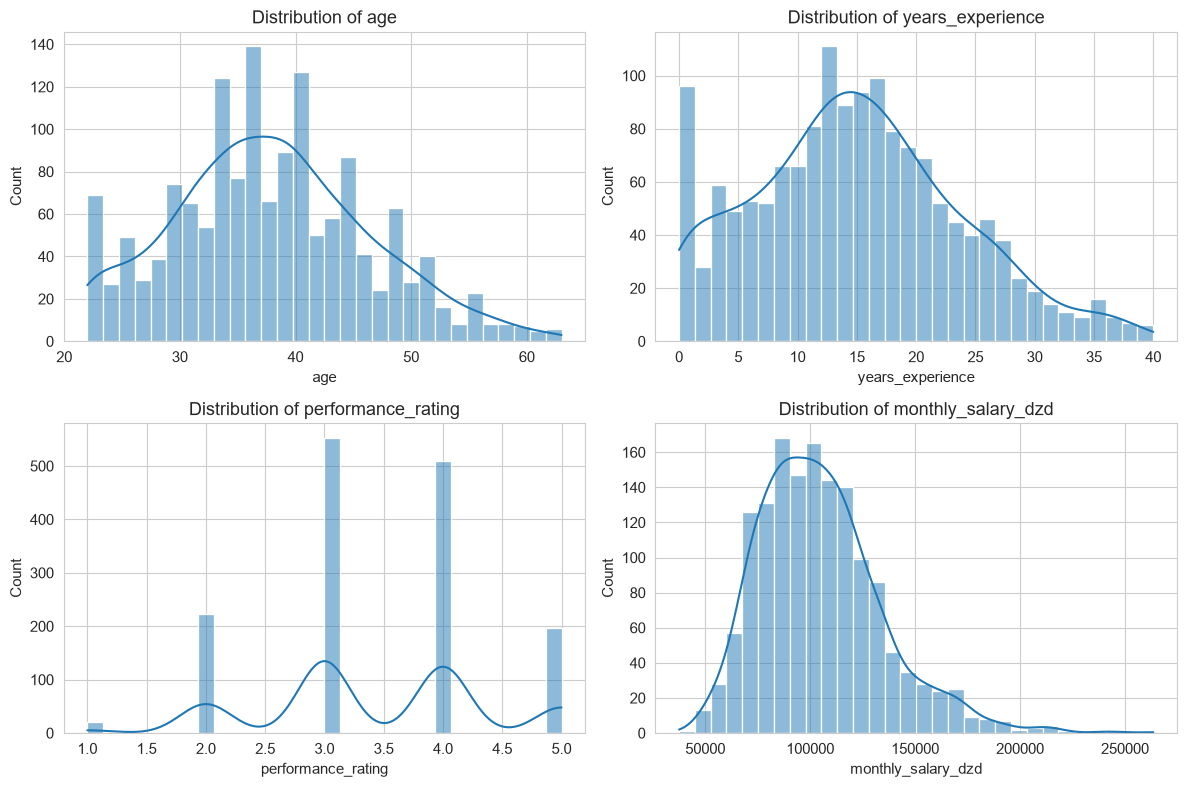

In [6]:
num_cols = ["age", "years_experience", "performance_rating", "monthly_salary_dzd"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

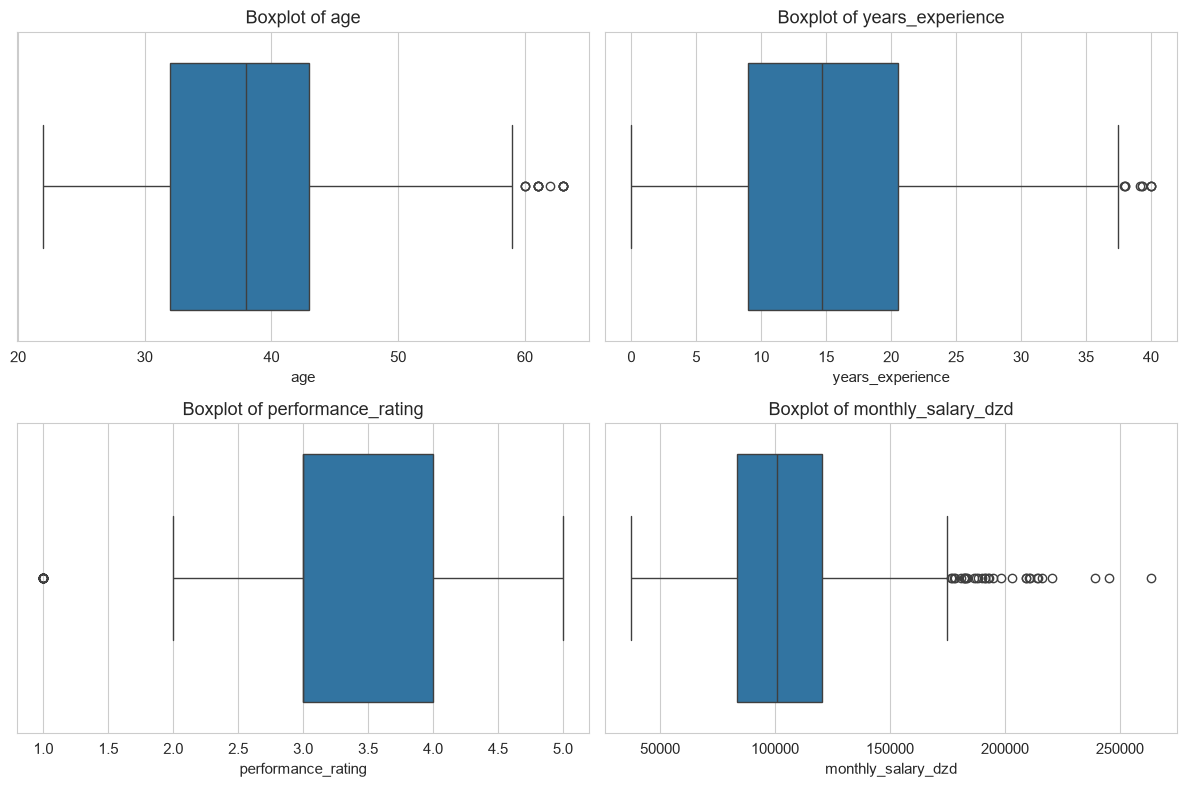

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

**Reading the plots:** `monthly_salary_dzd` is right-skewed with a handful of very
high earners flagged as boxplot outliers — likely senior Product Manager / Data
Scientist employees, not data errors, but we'll still decide how to handle them before
modelling.


---
## 4. EDA — categorical features


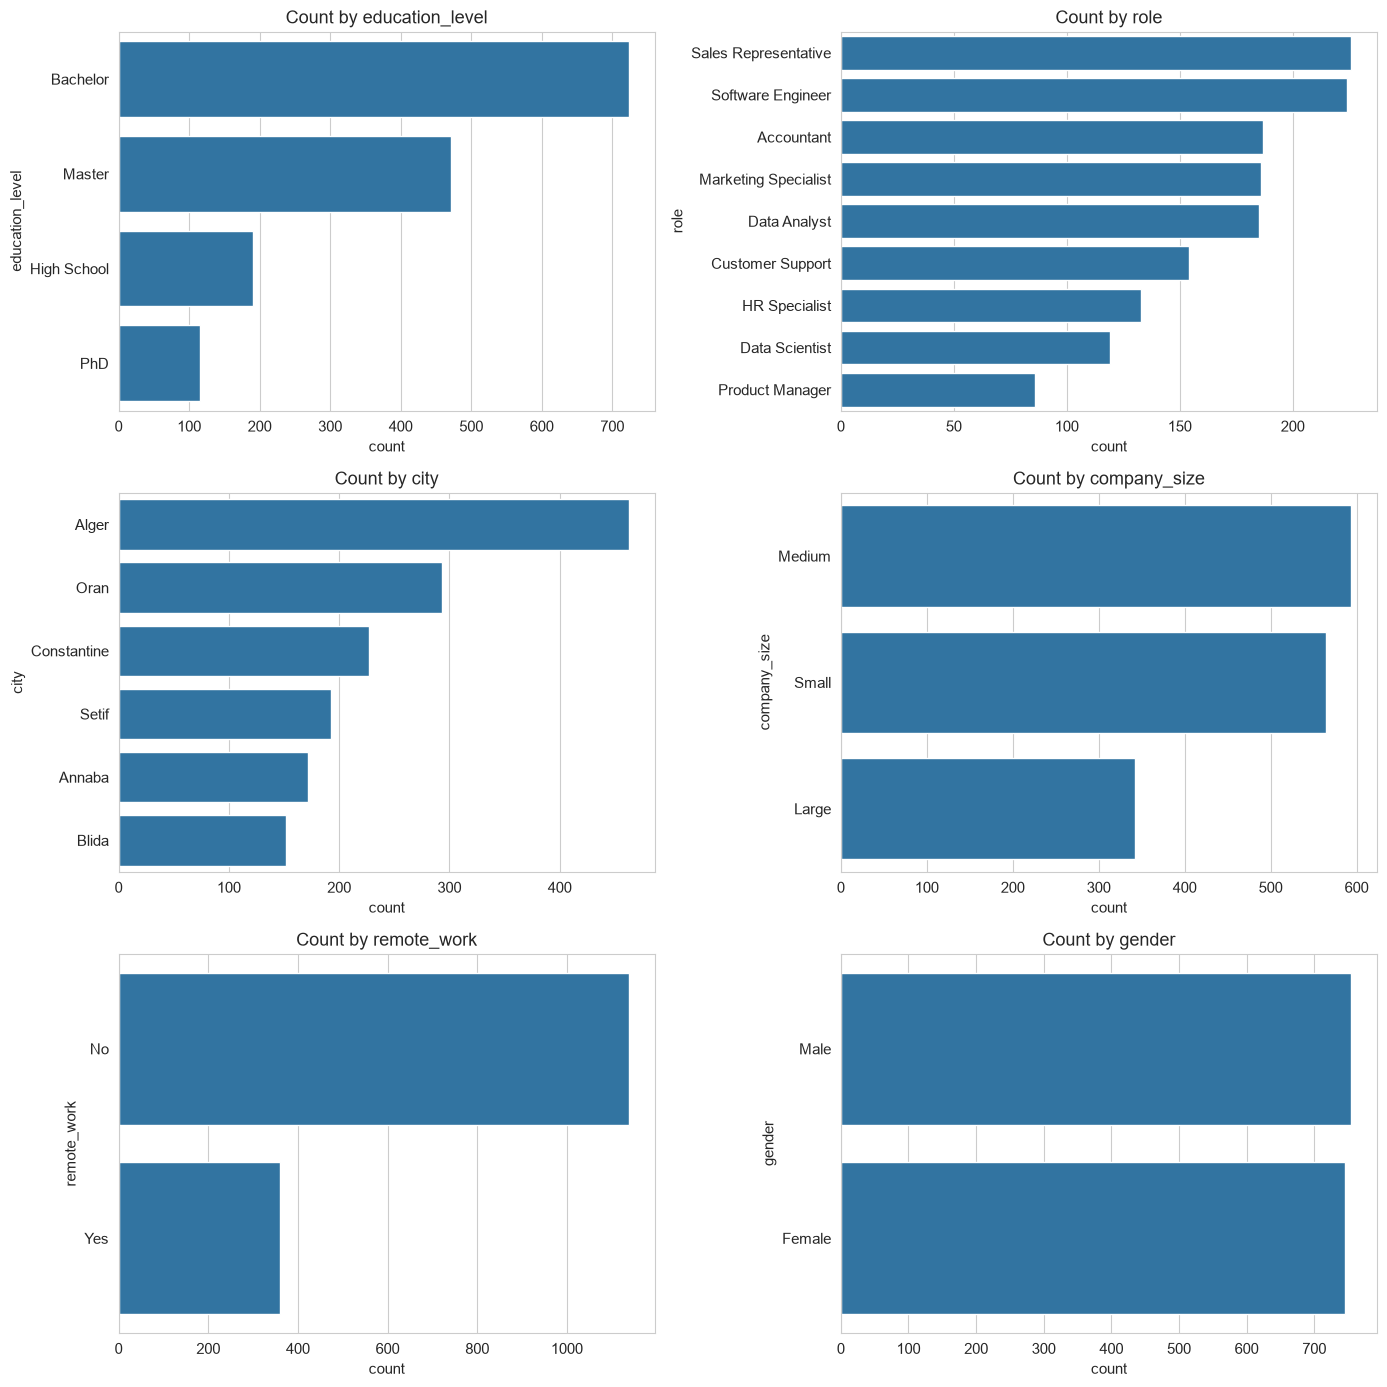

In [8]:
cat_cols = ["education_level", "role", "city", "company_size", "remote_work", "gender"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f"Count by {col}")
plt.tight_layout()
plt.show()

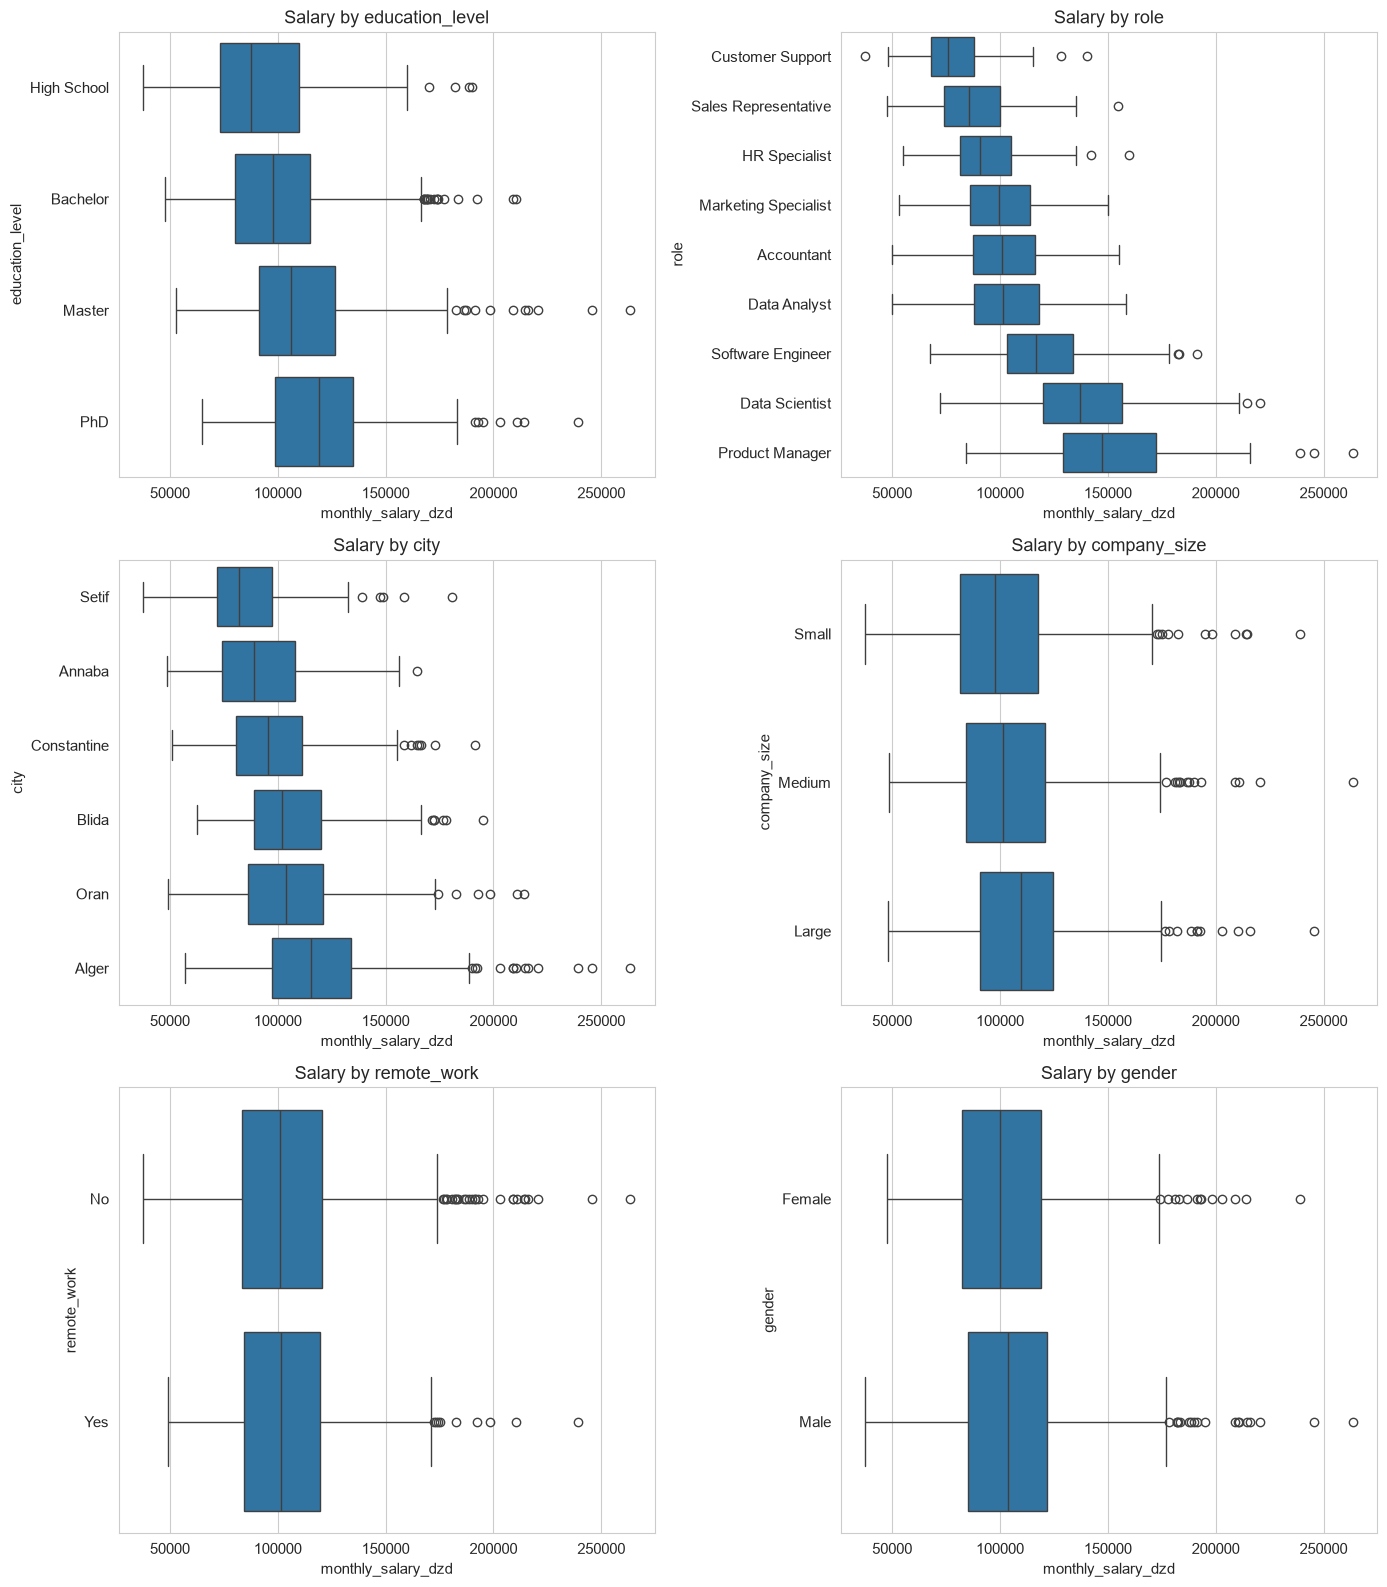

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
for ax, col in zip(axes.flatten(), cat_cols):
    order = df.groupby(col)["monthly_salary_dzd"].median().sort_values().index
    sns.boxplot(data=df, x="monthly_salary_dzd", y=col, order=order, ax=ax)
    ax.set_title(f"Salary by {col}")
plt.tight_layout()
plt.show()

**Reading the plots:** `role` and `city` clearly separate salary into different
levels — exactly what we'd expect a good model to pick up on. `education_level` also
separates salary, and does so in the **same order** as its natural ranking (High School
< Bachelor < Master < PhD) — a strong hint that we should encode it as an **ordinal**
feature (0, 1, 2, 3) rather than one-hot, so the model can see that order. `remote_work`
looks essentially flat across both groups — a first hint it may not carry real signal.


---
## 5. Detecting & removing outliers


In [10]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_cols = ["years_experience", "monthly_salary_dzd"]
mask = pd.Series(True, index=df.index)

for col in outlier_cols:
    low, high = iqr_bounds(df[col])
    col_mask = df[col].between(low, high)
    print(f"{col}: IQR bounds = ({low:,.1f}, {high:,.1f})  -> removes {(~col_mask).sum()} rows")
    mask &= col_mask

df_clean = df[mask].reset_index(drop=True)
print(f"\nRows before: {len(df)}   Rows after: {len(df_clean)}   Removed: {len(df) - len(df_clean)}")

years_experience: IQR bounds = (-8.3, 37.8)  -> removes 9 rows
monthly_salary_dzd: IQR bounds = (28,000.0, 176,000.0)  -> removes 32 rows

Rows before: 1500   Rows after: 1463   Removed: 37


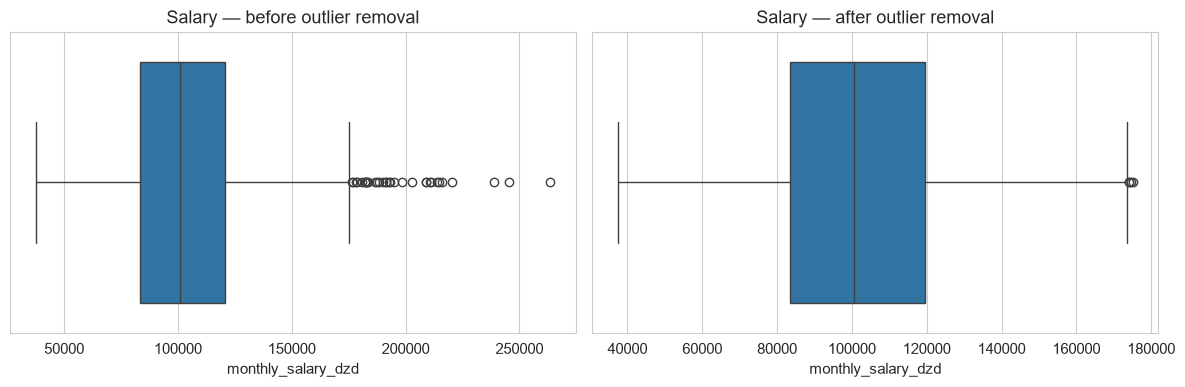

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="monthly_salary_dzd", ax=axes[0])
axes[0].set_title("Salary — before outlier removal")
sns.boxplot(data=df_clean, x="monthly_salary_dzd", ax=axes[1])
axes[1].set_title("Salary — after outlier removal")
plt.tight_layout()
plt.show()

**Method:** the classic IQR rule — anything more than 1.5×IQR below Q1 or above Q3
is flagged as an outlier. We applied it to `years_experience` and `monthly_salary_dzd`,
the two continuous columns most likely to have extreme values distort a regression fit.
We keep going with `df_clean` from here on.


---
## 6. Choosing features & target


In [12]:
df_model = df_clean.drop(columns=["employee_id", "age"])

target = "monthly_salary_dzd"
print("Features going in:", [c for c in df_model.columns if c != target])

Features going in: ['years_experience', 'education_level', 'role', 'city', 'company_size', 'performance_rating', 'remote_work', 'gender']


We drop `employee_id` (just a label, no information) and `age`. `age` and
`years_experience` measure almost the same thing for a working adult, and keeping
both raw numeric columns in a regression makes their individual coefficients unstable
and hard to interpret. Since `years_experience` is the more directly meaningful variable
for an HR salary model, we keep it and drop `age`. Everything else becomes a feature.


---
## 7. Transforming the data — encoding


In [13]:
# education_level has a real order -> map it to 0,1,2,3 (ordinal), NOT one-hot
education_order = ["High School", "Bachelor", "Master", "PhD"]
edu_map = {level: i for i, level in enumerate(education_order)}
df_model["education_level"] = df_model["education_level"].map(edu_map)

# role, city, company_size, remote_work, gender have NO natural order -> one-hot encode
nominal_cols = ["role", "city", "company_size", "remote_work", "gender"]
df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True)

X = df_model.drop(columns=[target])
y = df_model[target]

print("Final feature matrix:", X.shape)
X.head()

Final feature matrix: (1463, 20)


,years_experience,education_level,performance_rating,role_Customer Support,role_Data Analyst,role_Data Scientist,role_HR Specialist,role_Marketing Specialist,role_Product Manager,role_Sales Representative,role_Software Engineer,city_Annaba,city_Blida,city_Constantine,city_Oran,city_Setif,company_size_Medium,company_size_Small,remote_work_Yes,gender_Male
0,5.40,2,2,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,True
1,0.00,1,5,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,True
2,9.40,1,4,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False
3,12.90,2,4,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,True
4,5.50,0,4,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True


- `education_level` becomes a single 0/1/2/3 column — this **preserves the ranking**
  (High School < Bachelor < Master < PhD) instead of treating the four levels as
  unrelated categories.
- `role`, `city`, `company_size`, `remote_work`, `gender` have **no** natural order, so
  they're one-hot encoded (`drop_first=True` avoids the dummy-variable trap).

We'll add the `StandardScaler` step per-model below, right before fitting — that keeps
each model's data prep visible next to the model itself.


---
## 8. Train / test split


In [14]:
# TODO — split the data into training and test sets
#
#   Use train_test_split (already imported above):
#     - inputs:  X, y
#     - test_size=0.2          (hold out 20% of employees for testing)
#     - random_state=RANDOM_STATE   (so everyone gets the same split)
#   Name the four outputs exactly:  X_train, X_test, y_train, y_test
#   (every cell from here on depends on these four names existing)

# YOUR CODE HERE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 1170
Test set size: 293


In [15]:
def report(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    r2_train   = r2_score(y_train_true, y_train_pred)
    r2_test    = r2_score(y_test_true, y_test_pred)
    mse_train  = mean_squared_error(y_train_true, y_train_pred)
    mse_test   = mean_squared_error(y_test_true, y_test_pred)
    rmse_train = np.sqrt(mse_train)
    rmse_test  = np.sqrt(mse_test)
    print(f"{name}")
    print(f"  R²   -> train: {r2_train:.3f}   test: {r2_test:.3f}")
    print(f"  MSE  -> train: {mse_train:,.0f}   test: {mse_test:,.0f}")
    print(f"  RMSE -> train: {rmse_train:,.0f} DZD   test: {rmse_test:,.0f} DZD")
    return {"model": name, "r2_train": r2_train, "r2_test": r2_test,
            "mse_train": mse_train, "mse_test": mse_test,
            "rmse_train": rmse_train, "rmse_test": rmse_test}

results = []

**Why RMSE, alongside MSE?** MSE squares the errors, so it's measured in DZD² —
useful for training, but not something a human can read at a glance (a value like
600,000,000 says nothing on its own). **RMSE is just √MSE**, which brings the number
back into the same unit as the target: DZD. An RMSE of 24,600 DZD means "this model is
typically off by about 24,600 DZD per employee" — a number we can directly compare to
the average salary (~105,000 DZD) to judge whether that error is big or small. Report
both in every model below, but RMSE is the one worth quoting to the client.


---
## 9. Model 1 — Simple Linear Regression
### `years_experience` alone → `monthly_salary_dzd`

We start with the single most obvious predictor, before adding anything else, so we
have a baseline to compare against.


In [16]:
# TODO — Model 1: Simple Linear Regression
#
# Feature(s) to use: ONLY "years_experience" — that's what makes it "simple".
#
# Steps:
#   1. Select the years_experience column from X_train and X_test.
#      Keep it as a DataFrame (not a Series) with double brackets:
#      X_train[["years_experience"]]
#   2. Create a StandardScaler, fit it on the TRAINING column only, then use
#      that SAME fitted scaler to transform both train and test
#      (never fit a scaler on test data — that would leak information)
#   3. Create a LinearRegression and fit it on the scaled training data
#   4. Predict on the scaled training data AND the scaled test data
#   5. Call report(...) with a name string, y_train, your train predictions,
#      y_test, your test predictions — and append the returned dict to `results`

# YOUR CODE HERE

X_train_years = X_train[["years_experience"]]
X_test_years = X_test[["years_experience"]]
#rename them,to prevent later cells to train on wrong data.
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train_years, y_train)

train_predictions = linear_model.predict(X_train_years)
test_predictions = linear_model.predict(X_test_years)

linear_score = (linear_model.score(X_train_years, y_train), linear_model.score(X_test_years, y_test))
results.append(
    report(
        "Simple Linear Regression",
        y_train,
        train_predictions,
        y_test,
        test_predictions
    )
)

Simple Linear Regression
  R²   -> train: 0.129   test: 0.222
  MSE  -> train: 604,842,234   test: 509,408,698
  RMSE -> train: 24,594 DZD   test: 22,570 DZD


**Reading the result:** experience alone captures *some* of the picture, but R² is
far from great, and the RMSE is close to a quarter of the average salary — which makes
sense, since two employees with the same experience can have very different salaries if
they're in different roles or cities. That's exactly what multiple regression is for.


---
## 10. Model 2 — Multiple Linear Regression
### All features → `monthly_salary_dzd`


In [17]:
# TODO — Model 2: Multiple Linear Regression
#
# Feature(s) to use: EVERY column in X_train / X_test — years_experience,
# performance_rating, education_level, and all the one-hot role/city/
# company_size/remote_work/gender columns. That's what makes it "multiple".
#
# Steps:
#   1. Create a StandardScaler, fit it on X_train (all columns this time,
#      not a subset), then transform both X_train and X_test with it
#   2. Create a LinearRegression and fit it on the scaled training data
#   3. Predict on the scaled train and scaled test data
#   4. report(...) and append the result to `results`

# YOUR CODE HERE

# Convert categorical columns to numbers
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Make sure both datasets have the same columns
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

multiple_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

multiple_linear.fit(X_train_encoded, y_train)

train_predictions = multiple_linear.predict(X_train_encoded)
test_predictions = multiple_linear.predict(X_test_encoded)

results.append(
    report(
        "Multiple Linear Regression",
        y_train,
        train_predictions,
        y_test,
        test_predictions
    )
)

Multiple Linear Regression
  R²   -> train: 0.880   test: 0.869
  MSE  -> train: 83,617,176   test: 85,731,318
  RMSE -> train: 9,144 DZD   test: 9,259 DZD


**Reading the result:** adding role, city, education, company size and performance
should lift R² substantially over Model 1, and the RMSE should drop a lot too — a much
tighter typical error in DZD terms. This is the model Atlas HR Consulting would actually
hand to the client for salary benchmarking.


---
## 11. Model 3 — Polynomial Regression
### Letting `years_experience` curve


In [18]:
# TODO — Model 3: Polynomial Regression
#
# Feature(s) to expand polynomially: ONLY "years_experience" and
# "performance_rating" — squaring a one-hot (0/1) column does nothing useful
# (0²=0, 1²=1), so leave every other column linear.
#
# Steps:
#   1. num_cols_poly = ["years_experience", "performance_rating"]
#      other_cols     = every column in X_train that is NOT in num_cols_poly
#   2. Create PolynomialFeatures(degree=2, include_bias=False):
#        - fit_transform it on X_train[num_cols_poly]
#        - transform (NOT fit_transform) X_test[num_cols_poly]
#   3. Fit a StandardScaler on the polynomial-expanded TRAINING array, then
#      transform both the train and test polynomial arrays with it
#   4. Stack the scaled polynomial columns back together with the untouched
#      other_cols using np.hstack([...]) — once for train, once for test
#   5. Fit a LinearRegression on the final stacked training array
#   6. Predict on the final train/test arrays, report(...), append to `results`

# YOUR CODE HERE

num_cols_poly = ["years_experience", "performance_rating"]
other_cols = [col for col in X_train.columns if col not in num_cols_poly]

# 1. Encode categorical columns
X_train_encoded = pd.get_dummies(
    X_train[other_cols],
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test[other_cols],
    drop_first=True
)

# Make sure train and test have the same columns
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

# 2. Polynomial expansion
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(
    X_train[num_cols_poly]
)

X_test_poly = poly.transform(
    X_test[num_cols_poly]
)

# 3. Scale polynomial features
scaler_poly = StandardScaler()

X_train_poly_scaled = scaler_poly.fit_transform(
    X_train_poly
)

X_test_poly_scaled = scaler_poly.transform(
    X_test_poly
)

# 4. Stack polynomial + encoded columns
X_train_final = np.hstack([
    X_train_poly_scaled,
    X_train_encoded.values
])

X_test_final = np.hstack([
    X_test_poly_scaled,
    X_test_encoded.values
])

# 5. Fit Linear Regression
polynomial_regression = LinearRegression()

polynomial_regression.fit(
    X_train_final,
    y_train
)

# 6. Predictions
train_predictions = polynomial_regression.predict(
    X_train_final
)

test_predictions = polynomial_regression.predict(
    X_test_final
)

# 7. Report results
results.append(
    report(
        "Polynomial Regression",
        y_train,
        train_predictions,
        y_test,
        test_predictions
    )
)

Polynomial Regression
  R²   -> train: 0.888   test: 0.878
  MSE  -> train: 77,990,138   test: 79,812,301
  RMSE -> train: 8,831 DZD   test: 8,934 DZD


**Why try this at all?** Go back to the histogram in §3 — salary doesn't just grow
with experience, it grows **fast at first and slows down later** (a junior's first few
years matter a lot more to their paycheck than a senior's 25th vs 26th year). A straight
line can't bend to fit that; a degree-2 polynomial term on `years_experience` can. If R²
and RMSE both improve here over Model 2, that curve is real and worth keeping.


---
## 12. Comparing all three models


In [19]:
results_df = pd.DataFrame(results).set_index("model")
results_df

,r2_train,r2_test,mse_train,mse_test,rmse_train,rmse_test
model,,,,,,
Simple Linear Regression,0.13,0.22,"604,842,233.83","509,408,697.76","24,593.54","22,570.08"
Multiple Linear Regression,0.88,0.87,"83,617,175.85","85,731,318.08","9,144.24","9,259.12"
Polynomial Regression,0.89,0.88,"77,990,138.15","79,812,300.59","8,831.20","8,933.77"


**Take it back to the client:** the jump from Model 1 to Model 2 should show that
experience alone is not enough to benchmark salary fairly — role, city and education
matter just as much, and the RMSE column makes that concrete in real dinars, not just
as an abstract R² change. The jump (or lack of one) from Model 2 to Model 3 tells you
whether the *diminishing-returns* shape of experience is worth modelling explicitly, or
whether a straight line was already good enough once the other features were in the
picture.
